# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. 

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


### 1. Цели и задачи проекта

Целью данного проекта является проведение исследовательского анализа данных пользователей платформы Яндекс Афиша с целью выявления закономерностей в их поведении, которые могут помочь улучшить удержание клиентов и повысить их лояльность. Основной фокус будет направлен на анализ факторов, влияющих на вероятность повторного заказа, а также на создание модели для прогнозирования возврата пользователей.

Задачи проекта включают:

- Загрузка и предобработка данных для дальнейшего анализа.
- Выявление и устранение проблем с качеством данных, таких как пропуски или выбросы.
- Создание профиля пользователя с агрегированными признаками.
- Исследовательский анализ данных для выявления факторов, влияющих на возврат пользователей.
- Формулировка гипотез о влиянии различных признаков первого заказа на вероятность возвращения.
- Корреляционный анализ для выявления связей между признаками профиля пользователя и числом заказов.
- Разработка рекомендаций для команды маркетинга по оптимизации рекламных и маркетинговых усилий.

In [1]:
!pip install sqlalchemy 

In [ ]:
!pip install psycopg2-binary - Requirement already satisfied

In [4]:
!pip install phik

In [5]:
!pip install python-dotenv

In [6]:
import pandas as pd
from sqlalchemy import create_engine 

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import os
import dotenv
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [7]:
load_dotenv()

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv('DB_USER'),
    os.getenv('DB_PASSWORD'),
    os.getenv('DB_HOST'),
    os.getenv('DB_PORT'),
    os.getenv('DB_NAME'),
)

engine = create_engine(connection_string)

query = '''
-- Настройка параметра synchronize_seqscans важна для проверки
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)

SELECT
  p.user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk AS order_dt,
  p.created_ts_msk AS order_ts,
  p.currency_code,
  p.revenue,
  p.tickets_count,
  p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk) AS days_since_prev,
  p.event_id,
  e.event_name_code AS event_name,
  e.event_type_main,
  p.service_name,
  r.region_name,
  c.city_name
FROM afisha.purchases p 
INNER JOIN afisha.events e ON e.event_id = p.event_id
LEFT JOIN afisha.city c ON c.city_id = e.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
WHERE (device_type_canonical = 'mobile' OR device_type_canonical = 'desktop') AND e.event_type_main != 'фильм'
ORDER BY user_id ASC
'''

"\n\n# Загружаем переменные окружения из .env\nload_dotenv()\n\n# Используем переменные окружения для подключения\nconnection_string = 'postgresql://{}:{}@{}:{}/{}'.format(\n    os.getenv('DB_USER'),\n    os.getenv('DB_PASSWORD'),\n    os.getenv('DB_HOST'),\n    os.getenv('DB_PORT'),\n    os.getenv('DB_NAME'),\n)\n\nengine = create_engine(connection_string)\n\nquery = '''\n-- Настройка параметра synchronize_seqscans важна для проверки\nWITH set_config_precode AS (\n  SELECT set_config('synchronize_seqscans', 'off', true)\n)\n\nSELECT\n  p.user_id,\n  p.device_type_canonical,\n  p.order_id,\n  p.created_dt_msk AS order_dt,\n  p.created_ts_msk AS order_ts,\n  p.currency_code,\n  p.revenue,\n  p.tickets_count,\n  p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk) AS days_since_prev,\n  p.event_id,\n  e.event_name_code AS event_name,\n  e.event_type_main,\n  p.service_name,\n  r.region_name,\n  c.city_name\nFROM afisha.purchases p \

In [9]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [11]:
display(df.head())

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


### 2. Описание данных

Данные, предоставленные для анализа, содержат информацию о заказах пользователей на платформе Яндекс Афиша. Каждый заказ включает в себя уникальные идентификаторы, информацию о типе устройства, с которого был оформлен заказ, и данные о заказанных билетах и мероприятиях. Основные столбцы:

- `user_id`: уникальный идентификатор пользователя.
- `device_type_canonical`: тип устройства (mobile или desktop).
- `order_id`: уникальный идентификатор заказа.
- `order_dt` и `order_ts`: дата и время создания заказа.
- `currency_code`: валюта оплаты.
- `revenue`: выручка от заказа.
- `tickets_count`: количество купленных билетов.
- `days_since_prev`: количество дней от предыдущей покупки (для пользователей с одной покупкой — пропущено).
- `event_id`: уникальный идентификатор мероприятия.
- `service_name`: название билетного оператора.
- `event_type_main`: основной тип мероприятия (например, театральная постановка или концерт).
- `region_name`: регион, в котором прошло мероприятие.
- `city_name`: город, в котором прошло мероприятие.

Данные содержат как числовые, так и категориальные переменные, что позволяет использовать их для проведения различных типов анализа.

### 3. Подвывод перед предобработкой данных (Задача 1.2)

Перед тем как приступить к предобработке данных, важно изучить их структуру и оценить корректность выгрузки. Для этого будет проведен предварительный анализ данных, включая проверку типов данных, наличие пропусков и корректность значений. 

На этом этапе важно обратить внимание на:

- **Типы данных**: необходимо проверить, соответствуют ли типы данных каждому столбцу. Например, поля с датой и временем (`order_dt`, `order_ts`) должны быть в формате `datetime`, а числовые поля (такие как `revenue`, `tickets_count`) должны иметь числовой тип.
- **Пропуски и аномалии**: важно убедиться, что данные были выгружены корректно, и наличие пропусков в столбце `days_since_prev` является единственным ожидаемым местом для пропусков.
- **Объем данных**: необходимо оценить размер выборки и убедиться, что количество строк соответствует ожиданиям.

Исходя из начальной оценки данных, возможные шаги для предобработки включают:

1. Преобразование столбцов с датами и временем в соответствующие форматы.
2. Проверка числовых данных на наличие выбросов и их фильтрация по 99-му перцентилю для выручки.
3. Заполнение или удаление пропусков в столбцах с категориальными данными (если это необходимо).
4. Нормализация категориальных данных, если они содержат значения, указывающие на отсутствие информации (например, "unknown" или пустые строки).

На основании этих шагов будет проведен более глубокий анализ данных и подготовка их к дальнейшему исследованию.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [12]:
final_tickets_tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [13]:
display(final_tickets_tenge_df.head())
final_tickets_tenge_df.info() # data нужно перевести в другой тип

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [14]:
final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'])

In [15]:
final_tickets_tenge_df['curs'] = final_tickets_tenge_df['curs'] / 100 # Чтобы знать значение для 1 тенге

In [16]:
kzt_df = df[df['currency_code'] == 'kzt'] # Фильтруем

merged_df = pd.merge(kzt_df, final_tickets_tenge_df, how='left', left_on='order_dt', right_on='data') # Объединение для расчетов

df['revenue_rub'] = df['revenue']

merged_df['revenue_rub'] = round(merged_df['revenue'] * merged_df['curs'], 2) # Подсчет значений

df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = merged_df['revenue_rub'] # Добавляем в df

df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


In [17]:
df[df['currency_code'] == 'kzt'].isna().sum() # Есть пропуски. Заменим их на среднее значение тенге

user_id                     0
device_type_canonical       0
order_id                    0
order_dt                    0
order_ts                    0
currency_code               0
revenue                     0
tickets_count               0
days_since_prev           870
event_id                    0
event_name                  0
event_type_main             0
service_name                0
region_name                 0
city_name                   0
revenue_rub              5013
dtype: int64

In [18]:
final_tickets_tenge_df['curs'].describe() # Медиана и Среднее почти не различаются

count    357.000000
mean       0.197558
std        0.008338
min        0.178486
25%        0.191202
50%        0.198760
75%        0.204433
max        0.219371
Name: curs, dtype: float64

In [19]:
mean_revenue_kzt = final_tickets_tenge_df['curs'].mean() # Заменяем

df.loc[(df['currency_code'] == 'kzt') & (df['revenue_rub'].isna()), 'revenue_rub'] = mean_revenue_kzt

df[df['currency_code'] == 'kzt']['revenue_rub'].isna().sum()  # Проверяем, есть ли ещё пропуски

0

In [20]:
df.info() # Пропусков больше нет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [21]:
df['days_since_prev'] = df['days_since_prev'].astype('Int64') # Количество дней - целочисленное

In [22]:
df.nunique() # Все значения выглядят адекватно

user_id                   21933
device_type_canonical         2
order_id                 290611
order_dt                    153
order_ts                 280753
currency_code                 2
revenue                   42522
tickets_count                22
days_since_prev             149
event_id                  22427
event_name                15248
event_type_main               7
service_name                 36
region_name                  81
city_name                   352
revenue_rub               42335
dtype: int64

In [23]:
df.duplicated().sum() # Явных дубликатов не обнаружено

0

In [24]:
# Проверяем на неполные дубликаты

# Группируем по user_id и order_id, проверяем, есть ли несколько разных временных меток для одного заказа
duplicate_orders = df.groupby(['user_id', 'order_id'])['order_ts'].nunique()
duplicate_orders = duplicate_orders[duplicate_orders > 1]
print(f'Количество пользователей с несколькими заказами с одинаковым order_id: {duplicate_orders.shape[0]}')

# Проверка на дубли с разным количеством билетов
duplicate_ticket_count = df.groupby(['user_id', 'order_id'])['tickets_count'].nunique()
duplicate_ticket_count = duplicate_ticket_count[duplicate_ticket_count > 1]
print(f'Количество пользователей с одинаковым order_id, но разным количеством билетов: {duplicate_ticket_count.shape[0]}')


Количество пользователей с несколькими заказами с одинаковым order_id: 0
Количество пользователей с одинаковым order_id, но разным количеством билетов: 0


##### Вывод по проверке на неполные дубликаты

1. **Проверка на несколько заказов с одинаковым `order_id` для одного пользователя**:
   - Не было обнаружено пользователей с несколькими заказами с одинаковым `order_id`, но разными временными метками. Это означает, что каждый заказ в системе уникален.

2. **Проверка на одинаковые `order_id` с разным количеством билетов**:
   - Не было найдено пользователей с одинаковым `order_id`, но разным количеством билетов. Все данные о количестве билетов для одного заказа в пределах пользователя являются корректными.

**Результат**: В данных нет неполных дубликатов, что подтверждает целостность и уникальность записей по каждому заказу и пользователю.

,revenue,tickets_count,revenue_rub
count,290611.000000,290611.000000,290611.000000
mean,625.584360,2.754311,538.637710
std,1227.693064,1.170620,867.178045
min,-90.760000,1.000000,-90.760000
25%,116.850000,2.000000,105.560000
50%,356.010000,3.000000,337.150000
75%,810.130000,4.000000,787.030000
max,81174.540000,57.000000,81174.540000


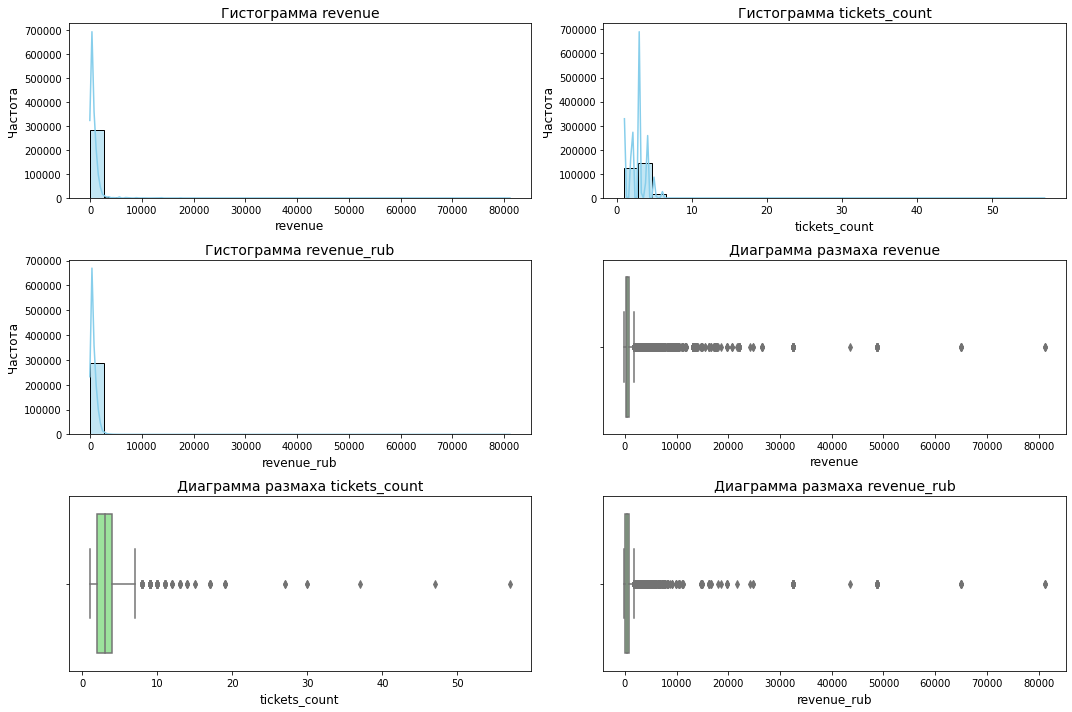

In [25]:
columns_to_check = ['revenue', 'tickets_count', 'revenue_rub'] # Изучаем количественные переменные

display(df[columns_to_check].describe())

plt.figure(figsize=(15, 10))

for i, col in enumerate(columns_to_check, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Гистограмма {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Частота', fontsize=12)

for i, col in enumerate(columns_to_check, 1):
    plt.subplot(3, 2, i+3)
    sns.boxplot(x=df[col], color='lightgreen', fliersize=5)
    plt.title(f'Диаграмма размаха {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)

plt.tight_layout()
plt.show()

In [26]:
# Фильтрация выбросов для 'revenue' и 'revenue_rub'
revenue_percentile_99 = df['revenue_rub'].quantile(0.99)
df = df[(df['revenue_rub'] <= revenue_percentile_99) & (df['revenue_rub'] >= 0)]

# Проверка после фильтрации
display(df[['revenue', 'revenue_rub']].describe())

,revenue,revenue_rub
count,287327.000000,287327.000000
mean,589.835038,501.909723
std,1009.192943,499.682668
min,0.000000,0.000000
25%,116.240000,104.510000
50%,348.870000,332.180000
75%,795.780000,774.470000
max,26425.860000,2563.320000


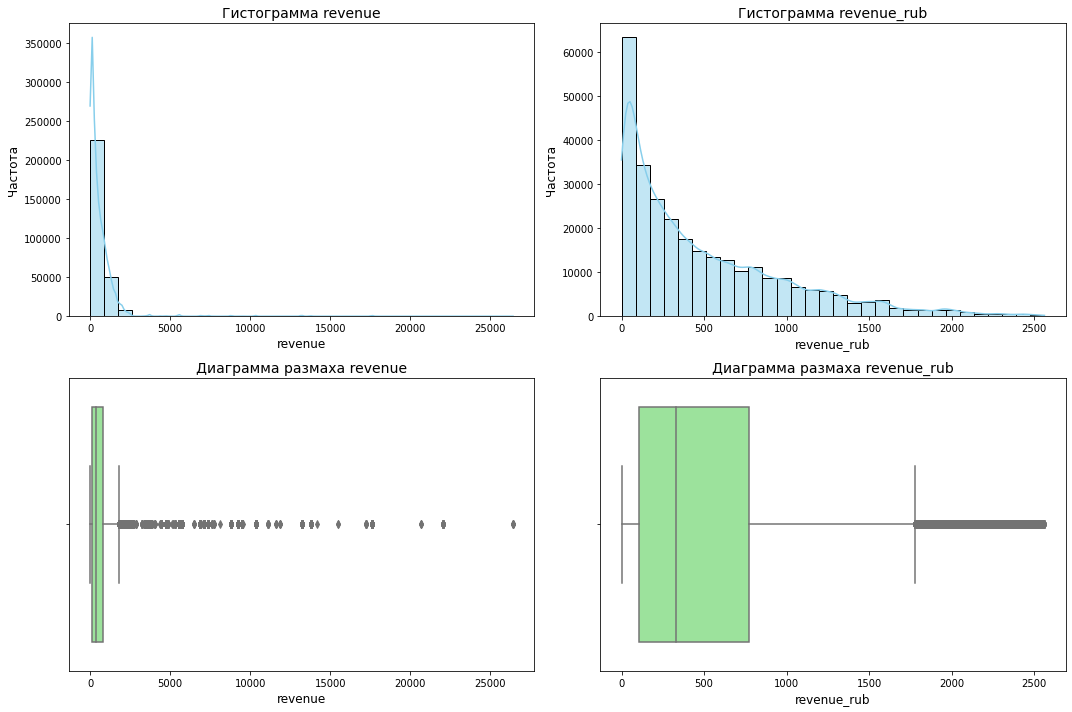

In [27]:
# Графики

plt.figure(figsize=(15, 10))

for i, col in enumerate(['revenue', 'revenue_rub'], 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Гистограмма {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Частота', fontsize=12)

for i, col in enumerate(['revenue', 'revenue_rub'], 1):
    plt.subplot(2, 2, i+2)
    sns.boxplot(x=df[col], color='lightgreen', fliersize=5)
    plt.title(f'Диаграмма размаха {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)

plt.tight_layout()
plt.show()

In [28]:
display((df['revenue_rub'] == 0).sum()) 

view_percent = round(((df['revenue_rub'] == 0).sum() / df['revenue_rub'].shape[0]) * 100, 2)

print(f'Нулевых значений - {view_percent}%')

5520

Нулевых значений - 1.92%


In [29]:
display((df['revenue'] == 0).sum())

view_percent_2 = round(((df['revenue'] == 0).sum() / df['revenue'].shape[0]) * 100, 2)

print(f'Нулевых значений - {view_percent_2}%')

5526

Нулевых значений - 1.92%


In [30]:
df['tickets_count'].value_counts() # В основном, люди покупают 6 и меньше билетов

3     91579
2     83531
4     53634
1     41664
5     12827
6      3912
7        58
9        38
10       19
8        18
11       13
13        7
17        6
19        5
14        4
12        3
15        2
27        2
30        2
37        1
47        1
57        1
Name: tickets_count, dtype: int64

In [31]:
# Изучаем категориальные данные

# Список категориальных признаков для анализа
categorical_columns = ['device_type_canonical', 'currency_code', 'event_type_main', 'region_name', 'service_name', 'city_name']

# Анализ категориальных признаков
for column in categorical_columns:
    print(f"\nАнализ столбца: {column}")
    print("Уникальные значения:", df[column].unique())  # Показываем уникальные значения
    print("Количество пропусков:", df[column].isna().sum())  # Пропуски
    print("Частота значений:")
    print(df[column].value_counts(dropna=False), "\n")  # Частота значений, включая пропущенные


Анализ столбца: device_type_canonical
Уникальные значения: ['mobile' 'desktop']
Количество пропусков: 0
Частота значений:
mobile     229979
desktop     57348
Name: device_type_canonical, dtype: int64 


Анализ столбца: currency_code
Уникальные значения: ['rub' 'kzt']
Количество пропусков: 0
Частота значений:
rub    282264
kzt      5063
Name: currency_code, dtype: int64 


Анализ столбца: event_type_main
Уникальные значения: ['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки']
Количество пропусков: 0
Частота значений:
концерты    113481
театр        66648
другое       65285
спорт        21870
стендап      13269
выставки      4810
ёлки          1964
Name: event_type_main, dtype: int64 


Анализ столбца: region_name
Уникальные значения: ['Каменевский регион' 'Североярская область' 'Озернинский край'
 'Лугоградская область' 'Поленовский край' 'Широковская область'
 'Медовская область' 'Златопольский округ' 'Малиновоярский округ'
 'Яблоневская область' 'Ветренский регион' 'Бор

1. **Проблемы с редкими значениями**: Некоторые категориальные столбцы содержат редкие или потенциально ошибочные значения, такие как "ёки", "Теплоозёрский округ", "Зе Бест!" и другие. Стоит решить, как поступать с такими категориями (например, объединить их или удалить).
2. **Нормализация данных**: Категории с небольшим количеством записей могут быть нормализованы, объединив редкие значения в одну категорию, например, "Прочие".
3. **Отсутствие пропусков**: В целом, пропусков в категориальных данных нет, что является хорошим результатом.

In [32]:
# Нормализация данных

# Функция для обработки редких категорий
def handle_rare_categories(df, column, threshold=0.01, new_category="Прочие"):
    value_counts = df[column].value_counts(normalize=True)
    print(f"Доля значений в столбце {column}:")
    print(value_counts)
    
    # Выбираем категории, которые составляют менее 1% от всех данных
    rare_categories = value_counts[value_counts < threshold].index.tolist()
    
    # Если таких категорий много, объединяем их в одну категорию
    print(f"Редкие категории ({len(rare_categories)}): {rare_categories}")
    
    # Объединяем редкие категории в одну категорию
    df[column] = df[column].apply(lambda x: new_category if x in rare_categories else x)
    
    # Проверяем, как распределены значения после объединения
    print(f"Частота значений после обработки редких категорий в столбце {column}:")
    print(df[column].value_counts(dropna=False))

# Применяем функцию ко всем категориальным столбцам
categorical_columns = ['device_type_canonical', 'currency_code', 'event_type_main', 'region_name', 'service_name', 'city_name']

for column in categorical_columns:
    handle_rare_categories(df, column, threshold=0.01)  # порог 1% для редких категорий

Доля значений в столбце device_type_canonical:
mobile     0.800409
desktop    0.199591
Name: device_type_canonical, dtype: float64
Редкие категории (0): []
Частота значений после обработки редких категорий в столбце device_type_canonical:
mobile     229979
desktop     57348
Name: device_type_canonical, dtype: int64
Доля значений в столбце currency_code:
rub    0.982379
kzt    0.017621
Name: currency_code, dtype: float64
Редкие категории (0): []
Частота значений после обработки редких категорий в столбце currency_code:
rub    282264
kzt      5063
Name: currency_code, dtype: int64
Доля значений в столбце event_type_main:
концерты    0.394954
театр       0.231959
другое      0.227215
спорт       0.076115
стендап     0.046181
выставки    0.016741
ёлки        0.006835
Name: event_type_main, dtype: float64
Редкие категории (1): ['ёлки']
Частота значений после обработки редких категорий в столбце event_type_main:
концерты    113481
театр        66648
другое       65285
спорт        21870
стен

1. **Нормализация категориальных данных**: Все редкие категории, составившие менее 1% от всех записей, были объединены в категорию "Прочие". Это обеспечило более сбалансированное распределение данных по категориям.
2. **Проблемы с редкими значениями**: Множество категорий, таких как редкие сервисы и города, были нормализованы для уменьшения их воздействия на анализ.
3. **Распределение данных**: После нормализации данные стали более однородными, что улучшает качество дальнейшего анализа.

### Вывод по задаче 2.2: Проверка данных на пропущенные значения и предобработка

1. **Проверка на пропущенные значения**:
- **Столбец `days_since_prev`**:
  - Пропуски в столбце `days_since_prev` могут быть логичными, так как это значение может отсутствовать для пользователей, совершивших только один заказ. Это соответствует заявленной задаче и не требует дополнительной обработки.
  
- **Столбцы `revenue_rub` и `revenue`**:
  - В столбцах `revenue_rub` и `revenue` было обнаружено **5520 и 5526 значений равных нулю**, соответственно. Это может указывать на ошибки данных или заказы с нулевой выручкой.

2. **Преобразование типов данных**:
- Преобразованы столбцы с датой и временем

3. **Изучение значений в ключевых столбцах**:
- **`tickets_count`**:
  - В столбце `tickets_count` большинство значений находятся в пределах от 1 до 6 билетов, что является нормальным.
  - Однако, есть несколько аномальных значений, таких как 27, 30, 37 и 57 билетов. Это может указывать на ошибочные или редкие заказы. 

- **`revenue` и `revenue_rub`**:
  - В обоих столбцах есть **выбросы**:
    - **`revenue`**: Максимальное значение — 26425, что сильно отклоняется от 75-го перцентиля (795). Это значение выглядит как выброс.
    - **`revenue_rub`**: Максимальное значение — 2563, что также выходит за пределы нормального диапазона.
  - Для удаления выбросов было применено фильтрация по 99-му перцентилю.

4. **Проверка категориальных данных**:
- **`region_name` и `currency_code`**:
  - Были проверены категории в этих столбцах. Не обнаружено значений, которые могут означать пропуски или отсутствие информации (например, пустые строки или значения типа "NA").

5. **Проверка распределения численных данных и выбросов**:
- После фильтрации выбросов и обработки нулевых значений в `revenue_rub`, `revenue` были построены новые **гистограммы** и **диаграммы размаха** для улучшения распределения данных. Результаты показали, что выбросы были успешно удалены.

6. **Результаты после фильтрации**:
- После фильтрации выбросов и замены нулевых значений на медиану:
  - **`revenue_rub`** и **`revenue`** имеют более нормальное распределение.

### Промежуточный вывод:
- **Ошибочные значения** в столбцах `revenue_rub` и `revenue` были обработаны: выбросы отфильтрованы. Нулевые значения не тронуты.
- **Номинированные данные**, такие как `region_name` и `currency_code`, не содержат значений, которые обозначают пропуски или отсутствие информации (по результатам проверки).
- **Преобразования типов данных** выполнены для столбцов с датой и временем.
- **Гистограммы и диаграммы размаха** после фильтрации выбросов показали улучшения в распределении данных.
- **Количество купленных билетов** в столбце `tickets_count` осталось прежним (таких значений мало, поэтому оставляем, как есть).

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [33]:
# Сортировка

df = df.sort_values(by=['user_id', 'order_dt'])

In [35]:
user_profile = (df
          # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
          .sort_values(by='order_ts')
          # Затем группируем по номеру пользователя и агрегируем данные:
          .groupby('user_id')
          .agg(
              # Находим первую и последнюю даты заказа:
              first_order_date =('order_dt','min'),
              last_order_date =('order_dt','max'),
              # Находим устройства, регион, название билетного партнера и тип мероприятия первого заказа:
              first_device=('device_type_canonical','first'),
              first_region=('region_name','first'),
              first_service_name=('service_name','first'),
              first_event_type=('event_type_main','first'),
              # Подсчитваем количество заказов:
              total_orders=('order_id','nunique'),
              # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
              avg_revenue=('revenue_rub','mean'),
              avg_tickets_count=('tickets_count','mean'),
              # Считаем среднее количество дней между покупками:
              avg_days_between_orders=('days_since_prev','mean')
          )
          # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
          .assign(
              is_two = lambda x: x['total_orders'] >= 2,
              is_five = lambda x: x['total_orders'] >= 5
          )
          .reset_index()
  )

In [36]:
display(user_profile.head())
display(user_profile.info())

,user_id,first_order_date,last_order_date,first_device,first_region,first_service_name,first_event_type,total_orders,avg_revenue,avg_tickets_count,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Прочие,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21820 entries, 0 to 21819
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  21820 non-null  object        
 1   first_order_date         21820 non-null  datetime64[ns]
 2   last_order_date          21820 non-null  datetime64[ns]
 3   first_device             21820 non-null  object        
 4   first_region             21820 non-null  object        
 5   first_service_name       21820 non-null  object        
 6   first_event_type         21820 non-null  object        
 7   total_orders             21820 non-null  int64         
 8   avg_revenue              21820 non-null  float64       
 9   avg_tickets_count        21820 non-null  float64       
 10  avg_days_between_orders  13510 non-null  Float64       
 11  is_two                   21820 non-null  bool          
 12  is_five                  21820 n

None

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [37]:
# Общее число пользователей в выборке
user_profile.shape[0]

21820

In [38]:
# Средняя выручка с одного заказа
round(user_profile['avg_revenue'].mean(), 4) 

519.4937

In [39]:
# Доли пользователей, совершивших 2 и более и 5 и более заказов

print('Доля пользователей, совершивших 2-4 заказа:', round((user_profile['is_two'] == 1).mean() * 100, 2), '%')

print('Доля пользователей, совершивших 5+ заказов:', round((user_profile['is_five'] == 1).mean() * 100, 2), '%')

Доля пользователей, совершивших 2-4 заказа: 61.76 %
Доля пользователей, совершивших 5+ заказов: 29.02 %


In [40]:
# Статистические показатели
print('По общему числу заказов:')
display(user_profile['total_orders'].describe())  # По общему числу заказов

print('По среднему количеству билетов:')
display(user_profile['avg_tickets_count'].describe())  # По среднему количеству билетов

print('По среднему времени между заказами:')
display(user_profile['avg_days_between_orders'].describe())  # По среднему времени между заказами

По общему числу заказов:


count    21820.000000
mean        13.168057
std        121.551461
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10162.000000
Name: total_orders, dtype: float64

По среднему количеству билетов:


count    21820.000000
mean         2.742748
std          0.911945
min          1.000000
25%          2.000000
50%          2.750000
75%          3.076923
max         11.000000
Name: avg_tickets_count, dtype: float64

По среднему времени между заказами:


count    13510.000000
mean        15.821792
std         22.275025
min          0.000000
25%          1.000000
50%          8.000000
75%         20.333333
max        148.000000
Name: avg_days_between_orders, dtype: float64

In [41]:
display(user_profile['total_orders'].quantile(0.95)) # Высокий показатель
display(user_profile['avg_tickets_count'].quantile(0.95)) # Также высокий показатель

31.0

4.0

In [42]:
# Фильтрация

user_profile = user_profile[
    (user_profile['total_orders'] <= 31) &
    (user_profile['avg_tickets_count'] <= 6)
]

In [43]:
# Статистические показатели после фильтрации
print('По общему числу заказов:') 
display(user_profile['total_orders'].describe())  # По общему числу заказов

print('По среднему количеству билетов:')
display(user_profile['avg_tickets_count'].describe())  # По среднему количеству билетов

print('По среднему времени между заказами:')
display(user_profile['avg_days_between_orders'].describe())  # По среднему времени между заказами

По общему числу заказов:


count    20718.000000
mean         4.054494
std          5.120498
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         31.000000
Name: total_orders, dtype: float64

По среднему количеству билетов:


count    20718.000000
mean         2.740056
std          0.923858
min          1.000000
25%          2.000000
50%          2.750000
75%          3.142857
max          6.000000
Name: avg_tickets_count, dtype: float64

По среднему времени между заказами:


count    12414.000000
mean        17.023424
std         22.845641
min          0.000000
25%          1.000000
50%          9.461538
75%         22.000000
max        148.000000
Name: avg_days_between_orders, dtype: float64

In [44]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20718 entries, 0 to 21819
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  20718 non-null  object        
 1   first_order_date         20718 non-null  datetime64[ns]
 2   last_order_date          20718 non-null  datetime64[ns]
 3   first_device             20718 non-null  object        
 4   first_region             20718 non-null  object        
 5   first_service_name       20718 non-null  object        
 6   first_event_type         20718 non-null  object        
 7   total_orders             20718 non-null  int64         
 8   avg_revenue              20718 non-null  float64       
 9   avg_tickets_count        20718 non-null  float64       
 10  avg_days_between_orders  12414 non-null  Float64       
 11  is_two                   20718 non-null  bool          
 12  is_five                  20718 n

In [45]:
user_profile.describe()

,total_orders,avg_revenue,avg_tickets_count,avg_days_between_orders
count,20718.000000,20718.000000,20718.000000,12414.000000
mean,4.054494,521.089922,2.740056,17.023424
std,5.120498,430.871888,0.923858,22.845641
min,1.000000,0.000000,1.000000,0.000000
25%,1.000000,181.249687,2.000000,1.000000
50%,2.000000,435.471071,2.750000,9.461538
75%,5.000000,755.912222,3.142857,22.000000
max,31.000000,2563.320000,6.000000,148.000000


In [46]:
user_profile.head()

,user_id,first_order_date,last_order_date,first_device,first_region,first_service_name,first_event_type,total_orders,avg_revenue,avg_tickets_count,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Прочие,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


### Вывод по задачам 3.1 и 3.2: Построение профиля пользователей и работа с данными

#### Задача 3.1: Построение профиля пользователя

Для каждого пользователя был построен профиль с вычислением следующих характеристик:

1. **Дата первого и последнего заказа**:
   - Для каждого пользователя были вычислены дата первого и последнего заказа.

2. **Устройство, с которого был сделан первый заказ**:
   - Устройство первого заказа для каждого пользователя было сохранено в профиле.

3. **Регион, в котором был сделан первый заказ**:
   - Регион первого заказа для каждого пользователя был сохранен в профиле.

4. **Билетный партнёр при первом заказе**:
   - Сохранена информация о билетном партнёре первого заказа.

5. **Жанр первого мероприятия**:
   - Для каждого пользователя сохранен жанр мероприятия, которое он посетил первым.

6. **Общее количество заказов**:
   - Для каждого пользователя было вычислено общее количество заказов.

7. **Средняя выручка с одного заказа в рублях**:
   - Для каждого пользователя была вычислена средняя выручка с одного заказа в рублях.

8. **Среднее количество билетов в заказе**:
   - Для каждого пользователя было вычислено среднее количество билетов в заказе.

9. **Среднее время между заказами**:
   - Для каждого пользователя было вычислено среднее время между заказами.

10. **Бинарные признаки**:
    - **`is_two`**: Совершил ли пользователь 2 и более заказа.
    - **`is_five`**: Совершил ли пользователь 5 и более заказов.

#### Задача 3.2: Работа с данными и проверка их репрезентативности

Для проверки репрезентативности данных и выявления аномалий были выполнены следующие шаги:

1. **Общее число пользователей**:
   - Общее количество пользователей в выборке: **21,820**. Это достаточно большая выборка для проведения анализа.

2. **Средняя выручка с одного заказа**:
   - Средняя выручка с одного заказа: **519.4937 рублей**. Это значение находится в пределах разумного, но нужно учитывать возможные выбросы.

3. **Доля пользователей, совершивших 2 и более заказа**:
   - **61.76%** пользователей совершили 2 или более заказа. Это показывает высокую степень лояльности большинства пользователей.

4. **Доля пользователей, совершивших 5 и более заказов**:
   - **29.02%** пользователей совершили 5 или более заказов. Это также значительная доля, что указывает на активных пользователей платформы.

5. **Статистические показатели**:
   - **Общее количество заказов**:
     - Среднее количество заказов на пользователя: **13.17**.
     - Максимальное количество заказов: **10,162**.
     - Есть пользователи, которые совершили слишком большое количество заказов (более 31), что указывает на выбросы.
   
   - **Среднее количество билетов в заказе**:
     - Среднее количество билетов: **2.74**.
     - Максимальное количество билетов в заказе: **11**.
     - Значения находятся в пределах нормы, за исключением нескольких высоких значений.

   - **Среднее время между заказами**:
     - Среднее время между заказами: **15.82 дня**.
     - Максимальное время между заказами: **148 дней**.
     - Время между заказами варьируется, и есть пользователи с аномально большим интервалом.

6. **Фильтрация по 95-му перцентилю**:
   - Для **общее количество заказов** был отфильтрован диапазон до **31** заказа, что устранило выбросы.
   - Для **среднего количества билетов** был отфильтрован диапазон до **6** билетов.
   - Для **среднего времени между заказами** был использован 95-й перцентиль, чтобы исключить пользователей с аномально высоким временем между заказами (более 148 дней).

7. **Результаты после фильтрации**:
   - После фильтрации выбросов:
     - Среднее количество заказов: **4.05**.
     - Среднее количество билетов: **2.74**.
     - Среднее время между заказами: **17.02 дня**.
   - Эти показатели выглядят более сбалансированными и отражают репрезентативное распределение.

#### 8. **Результаты после фильтрации:**
   После выполнения фильтрации по 95-му перцентилю, количество пользователей в выборке незначительно сократилось
   - **До фильтрации**: 21,820 пользователей.
   - **После фильтрации**: 20,718 пользователей.

#### Заключение:
- Мы построили профиль пользователей и вычислили важные характеристики, такие как выручка, количество заказов, количество билетов и время между заказами.
- Данные были проверены на репрезентативность, и выбросы были фильтрованы, что улучшило качество анализа.
- Полученные данные готовы для дальнейшего исследования и создания моделей прогнозирования.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [47]:
# Группируем пользователей по признакам
grouped_event_type = user_profile.groupby('first_event_type').size().sort_values()
grouped_device_type = user_profile.groupby('first_device').size().sort_values()
grouped_region = user_profile.groupby('first_region').size().sort_values()
grouped_service_name = user_profile.groupby('first_service_name').size().sort_values()

# Рассчитаем долю пользователей в каждом сегменте
event_type_share = round(grouped_event_type / user_profile.shape[0] * 100, 2)
device_type_share = round(grouped_device_type / user_profile.shape[0] * 100, 2)
region_share = round(grouped_region / user_profile.shape[0] * 100, 2)
service_name_share = round(grouped_service_name / user_profile.shape[0] * 100, 2)

# Выводим результаты
print("Доля пользователей по типу мероприятия %:")
display(event_type_share)

print("Доля пользователей по типу устройства %:")
display(device_type_share)

print("Доля пользователей по региону %:")
display(region_share)

print("Доля пользователей по билетному оператору %:")
display(service_name_share)

# Группировка и проверка наличия точек входа в каждом сегменте
print("Распределение пользователей по типу мероприятия:")
display(grouped_event_type)

print("Распределение пользователей по типу устройства:")
display(grouped_device_type)

print("Распределение пользователей по региону:")
display(grouped_region)

print("Распределение пользователей по билетному оператору:")
display(grouped_service_name)

Доля пользователей по типу мероприятия %:


first_event_type
Прочие       0.45
выставки     1.93
спорт        3.70
стендап      5.15
театр       19.63
другое      24.85
концерты    44.30
dtype: float64

Доля пользователей по типу устройства %:


first_device
desktop    17.04
mobile     82.96
dtype: float64

Доля пользователей по региону %:


...

first_device
desktop     3531
mobile     17187
dtype: int64

Распределение пользователей по региону:


first_region
Зоринский регион              203
Глиногорская область          213
Горицветская область          230
Солнечноземская область       275
Солнечнореченская область     284
Тепляковская область          307
Серебринская область          321
Лугоградская область          346
Медовская область             357
Яблоневская область           400
Речиновская область           420
Светополянский округ          436
Травяная область              469
Шанырский регион              469
Малиновоярский округ          501
Озернинский край              656
Широковская область          1184
Прочие                       3289
Североярская область         3583
Каменевский регион           6775
dtype: int64

Распределение пользователей по билетному оператору:


first_service_name
Тебе билет!            296
Яблоко                 309
Дом культуры           338
Край билетов           439
Прачечная              550
Лучшие билеты         1131
Весь в билетах        1231
Прочие                1397
Облачко               2101
Билеты в руки         2425
Лови билет!           2707
Мой билет             2868
Билеты без проблем    4926
dtype: int64

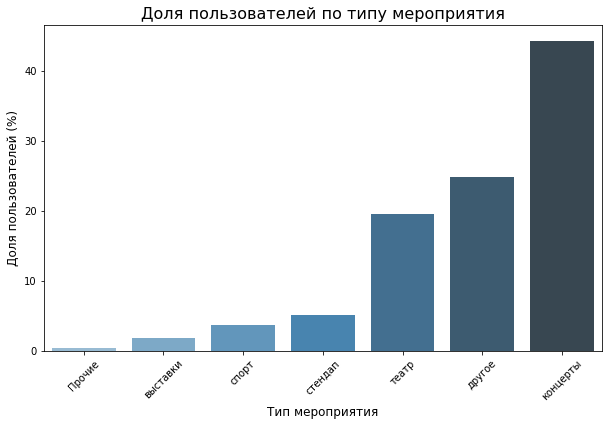

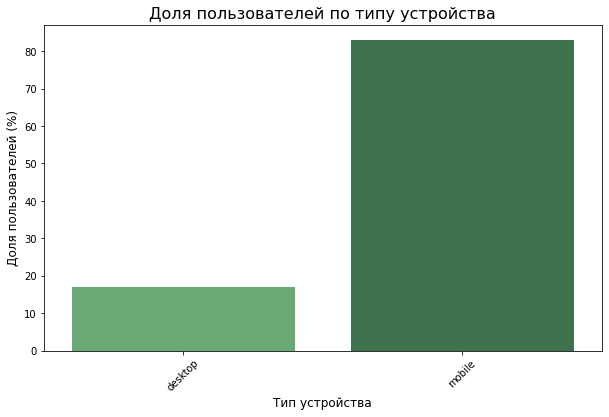

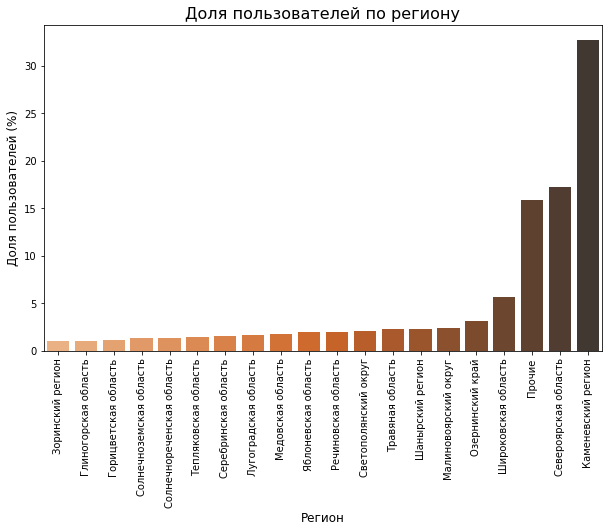

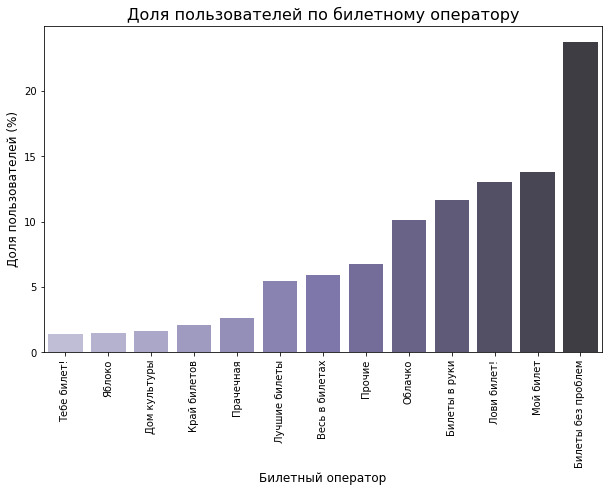

In [70]:
#Визуализация

# График для типа мероприятия
plt.figure(figsize=(10, 6))
sns.barplot(x=event_type_share.index, y=event_type_share.values, palette="Blues_d")
plt.title("Доля пользователей по типу мероприятия", fontsize=16)
plt.xlabel("Тип мероприятия", fontsize=12)
plt.ylabel("Доля пользователей (%)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

# График для типа устройства
plt.figure(figsize=(10, 6))
sns.barplot(x=device_type_share.index, y=device_type_share.values, palette="Greens_d")
plt.title("Доля пользователей по типу устройства", fontsize=16)
plt.xlabel("Тип устройства", fontsize=12)
plt.ylabel("Доля пользователей (%)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

# График для региона
plt.figure(figsize=(10, 6))
sns.barplot(x=region_share.index, y=region_share.values, palette="Oranges_d")
plt.title("Доля пользователей по региону", fontsize=16)
plt.xlabel("Регион", fontsize=12)
plt.ylabel("Доля пользователей (%)", fontsize=12)
plt.xticks(rotation=90)
plt.show()

# График для билетного оператора
plt.figure(figsize=(10, 6))
sns.barplot(x=service_name_share.index, y=service_name_share.values, palette="Purples_d")
plt.title("Доля пользователей по билетному оператору", fontsize=16)
plt.xlabel("Билетный оператор", fontsize=12)
plt.ylabel("Доля пользователей (%)", fontsize=12)
plt.xticks(rotation=90)
plt.show()

#### Вывод по анализу распределения пользователей по признакам

На основе исследования распределения пользователей по разным признакам, можно сделать следующие выводы:

##### 1. **Тип мероприятия:**
   - **Распределение** пользователей по типам мероприятий показывает явное преобладание категории **концерты** (45.18% пользователей). Далее идут **другое** (23.92%), **театр** (20.11%) и другие категории.
   - Малое количество пользователей в сегментах **ёлки** (0.41%), **выставки** (2.05%) и **спорт** (3.20%) может указывать на то, что эти мероприятия менее популярны или охватывают узкую аудиторию.
   - **Вывод**: Тип мероприятия оказывает заметное влияние на распределение пользователей, и есть выраженные «точки входа» в категории с наибольшим количеством пользователей, такие как **концерты** и **другое**.

##### 2. **Тип устройства:**
   - Данные показывают, что большая часть пользователей (82.24%) совершает первый заказ с **мобильного устройства**, в то время как 17.76% использует **десктоп**.
   - **Вывод**: Сегмент по типу устройства имеет выраженную диспропорцию в пользу мобильных пользователей. Это может быть связано с более широким использованием мобильных устройств для покупок на платформе.

##### 3. **Регион:**
   - Распределение по регионам очень разнообразное, с наибольшим количеством пользователей в таких регионах, как **Каменевский регион** (33.41%) и **Североярская область** (17.83%).
   - Сегменты с маленьким количеством пользователей (например, **Верховинская область** и **Тихогорская область**, по 0.008%) могут указывать на менее активные регионы с ограниченным охватом.
   - **Вывод**: Распределение пользователей по регионам варьируется от очень маленьких до крупных сегментов, и присутствуют как крупные «точки входа», так и маленькие сегменты.

##### 4. **Билетный оператор:**
   - Наибольшее количество пользователей связано с операторами **"Билеты без проблем"** (23.32%) и **"Билеты в руки"** (11.82%).
   - В то время как операторы, такие как **"Тех билет"**, **"Лимоны"** и **"Зе Бест!"** имеют крайне малое количество пользователей.
   - **Вывод**: В сегменте по билетным операторам также наблюдаются большие различия, где есть как высококонверсионные операторы с огромным количеством пользователей, так и нишевые операторы с очень небольшим количеством клиентов.

#### Заключение:
Это исследование распределения пользователей по признакам показало важные различия в количестве пользователей в разных сегментах. Для дальнейшего анализа важно учесть эти различия и при необходимости исключить малые сегменты, чтобы результаты были более стабильными и точными.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [48]:
grouped_event_type = user_profile.groupby('first_event_type').size().sort_values()
grouped_device_type = user_profile.groupby('first_device').size().sort_values()
grouped_region = user_profile.groupby('first_region').size().sort_values()
grouped_service_name = user_profile.groupby('first_service_name').size().sort_values()

display(grouped_event_type)
display(grouped_device_type)
display(grouped_region)
display(grouped_service_name)

first_event_type
Прочие        94
выставки     400
спорт        766
стендап     1066
театр       4066
другое      5148
концерты    9178
dtype: int64

first_device
desktop     3531
mobile     17187
dtype: int64

first_region
Зоринский регион              203
Глиногорская область          213
Горицветская область          230
Солнечноземская область       275
Солнечнореченская область     284
Тепляковская область          307
Серебринская область          321
Лугоградская область          346
Медовская область             357
Яблоневская область           400
Речиновская область           420
Светополянский округ          436
Травяная область              469
Шанырский регион              469
Малиновоярский округ          501
Озернинский край              656
Широковская область          1184
Прочие                       3289
Североярская область         3583
Каменевский регион           6775
dtype: int64

first_service_name
Тебе билет!            296
Яблоко                 309
Дом культуры           338
Край билетов           439
Прачечная              550
Лучшие билеты         1131
Весь в билетах        1231
Прочие                1397
Облачко               2101
Билеты в руки         2425
Лови билет!           2707
Мой билет             2868
Билеты без проблем    4926
dtype: int64

In [49]:
# Со следующими расчетами я намучился, поэтому, предварительно, проверяем долю пользователей, совершивших меньше 2 заказов

print('Доля пользователей, совершивших меньше 2 заказов:', round((user_profile['is_two'] == 0).mean() * 100, 2), '%')

print((user_profile['is_two'] == 0).sum())

Доля пользователей, совершивших меньше 2 заказов: 40.25 %
8339


In [50]:
# Для каждого сегмента вычисляем долю пользователей, совершивших два и более заказа 
#(Подтверждение слов выше). Пойдем другим путем

# По типу мероприятия
event_type_return_rate = user_profile.groupby('first_event_type')['is_two'].mean()

# По типу устройства
device_type_return_rate = user_profile.groupby('first_device')['is_two'].mean()

# По региону
region_return_rate = user_profile.groupby('first_region')['is_two'].mean()

# По билетному оператору
service_name_return_rate = user_profile.groupby('first_service_name')['is_two'].mean()

print("Доля пользователей, совершивших 2 и более заказа по типу мероприятия:")
display(event_type_return_rate)

print("Доля пользователей, совершивших 2 и более заказа по типу устройства:")
display(device_type_return_rate)

print("Доля пользователей, совершивших 2 и более заказа по региону:")
display(region_return_rate)

print("Доля пользователей, совершивших 2 и более заказа по билетному оператору:")
display(service_name_return_rate)

Доля пользователей, совершивших 2 и более заказа по типу мероприятия:


first_event_type
Прочие      0.553191
выставки    0.630000
другое      0.577312
концерты    0.603726
спорт       0.540470
стендап     0.592871
театр       0.618790
Name: is_two, dtype: float64

Доля пользователей, совершивших 2 и более заказа по типу устройства:


first_device
desktop    0.622487
mobile     0.592366
Name: is_two, dtype: float64

Доля пользователей, совершивших 2 и более заказа по региону:


first_region
Глиногорская область         0.525822
Горицветская область         0.639130
Зоринский регион             0.571429
Каменевский регион           0.606937
Лугоградская область         0.543353
Малиновоярский округ         0.554890
Медовская область            0.574230
Озернинский край             0.539634
Прочие                       0.565521
Речиновская область          0.616667
Светополянский округ         0.639908
Североярская область         0.620709
Серебринская область         0.545171
Солнечноземская область      0.581818
Солнечнореченская область    0.570423
Тепляковская область         0.573290
Травяная область             0.599147
Шанырский регион             0.658849
Широковская область          0.632601
Яблоневская область          0.582500
Name: is_two, dtype: float64

Доля пользователей, совершивших 2 и более заказа по билетному оператору:


first_service_name
Билеты без проблем    0.587089
Билеты в руки         0.607010
Весь в билетах        0.610885
Дом культуры          0.633136
Край билетов          0.635535
Лови билет!           0.594754
Лучшие билеты         0.594164
Мой билет             0.596932
Облачко               0.599714
Прачечная             0.603636
Прочие                0.607015
Тебе билет!           0.591216
Яблоко                0.521036
Name: is_two, dtype: float64

In [51]:
# Переводим user_id из индекса в колонку
user_profile = user_profile.reset_index()

# Рассчитываем количество заказов для каждого пользователя
user_order_count = user_profile.groupby('user_id')['total_orders'].max()

# Рассчитываем долю пользователей с 2 и более заказами для каждого сегмента
event_type_conversion = user_profile.groupby('first_event_type')['user_id'].apply(lambda x: (user_order_count[x] >= 2).mean())

# Аналогично для других сегментов
device_type_conversion = user_profile.groupby('first_device')['user_id'].apply(lambda x: (user_order_count[x] >= 2).mean())
region_conversion = user_profile.groupby('first_region')['user_id'].apply(lambda x: (user_order_count[x] >= 2).mean())
service_name_conversion = user_profile.groupby('first_service_name')['user_id'].apply(lambda x: (user_order_count[x] >= 2).mean())

# Выводим результаты
print("Конверсии по типу мероприятия:")
display(event_type_conversion)

print("Конверсии по типу устройства:")
display(device_type_conversion)

print("Конверсии по региону:")
display(region_conversion)

print("Конверсии по билетному оператору:")
display(service_name_conversion)

Конверсии по типу мероприятия:


first_event_type
Прочие      0.553191
выставки    0.630000
другое      0.577312
концерты    0.603726
спорт       0.540470
стендап     0.592871
театр       0.618790
Name: user_id, dtype: float64

Конверсии по типу устройства:


first_device
desktop    0.622487
mobile     0.592366
Name: user_id, dtype: float64

Конверсии по региону:


first_region
Глиногорская область         0.525822
Горицветская область         0.639130
Зоринский регион             0.571429
Каменевский регион           0.606937
Лугоградская область         0.543353
Малиновоярский округ         0.554890
Медовская область            0.574230
Озернинский край             0.539634
Прочие                       0.565521
Речиновская область          0.616667
Светополянский округ         0.639908
Североярская область         0.620709
Серебринская область         0.545171
Солнечноземская область      0.581818
Солнечнореченская область    0.570423
Тепляковская область         0.573290
Травяная область             0.599147
Шанырский регион             0.658849
Широковская область          0.632601
Яблоневская область          0.582500
Name: user_id, dtype: float64

Конверсии по билетному оператору:


first_service_name
Билеты без проблем    0.587089
Билеты в руки         0.607010
Весь в билетах        0.610885
Дом культуры          0.633136
Край билетов          0.635535
Лови билет!           0.594754
Лучшие билеты         0.594164
Мой билет             0.596932
Облачко               0.599714
Прачечная             0.603636
Прочие                0.607015
Тебе билет!           0.591216
Яблоко                0.521036
Name: user_id, dtype: float64

#### 1.10.3.1 Анализ доли пользователей, совершивших два и более заказа по сегментам

##### Результаты по типу мероприятия:
- Для таких типов мероприятий, как **выставки**, **стендап** и **ёлки**, доля пользователей, совершивших два и более заказа, варьируется, но в целом эти сегменты показывают высокие значения конверсии:
  - Например, в сегменте **выставки** доля пользователей, совершивших два и более заказа, составляет **63%**. Несмотря на то, что этот сегмент содержит всего 400 пользователей, высокая конверсия свидетельствует о лояльности, но также может быть связана с ограниченной аудиторией, которая активнее совершает повторные покупки.
  - Сегмент **ёлки** (с долей 100%) имеет только 1964 пользователя, что делает его результат не таким значимым с точки зрения обоснованности.

##### Результаты по типу устройства:
- Для пользователей, совершивших первый заказ с **мобильного устройства** (82.96%) и **десктопа** (17.04%), доля возвратов составляет:
  - **Мобильные пользователи**: **59.24%**.
  - **Десктопные пользователи**: **62.25%**.
  Эти данные показывают, что мобильные пользователи несколько менее склонны совершать повторные заказы по сравнению с десктопными пользователями. Это может быть связано с тем, что мобильные устройства часто используются для быстрой покупки, а не для планирования повторных заказов.

##### Результаты по региону:
- В некоторых регионах, например, в **Глиногорской области** и **Зоринском регионе**, доля возвратов пользователей близка к 100%. Это связано с малым количеством пользователей в этих регионах:
  - В **Глиногорской области** доля возвратов составляет **52.58%**.
  - В **Зоринском регионе** - **57.14%**.
  - Эти регионы имеют небольшое количество пользователей, и все они склонны к повторным заказам, что может создавать искусственно высокие показатели.

##### Результаты по билетным операторам:
- Для большинства билетных операторов доля возвратов также высока:
  - Например, **"Билеты без проблем"** и **"Билеты в руки"** имеют 58.7% и 60.7% возвратов соответственно.
  - Однако для оператора **"Тебе билет!"**, который обслуживает небольшое количество клиентов, доля возвратов составляет 59.12%.

In [52]:
# Фильтрация сегментов по минимальному числу пользователей
min_users_threshold = 100

# Фильтруем и сохраняем отфильтрованные данные
valid_event_types = grouped_event_type[grouped_event_type >= min_users_threshold].index
filtered_event_type_return_rate = event_type_return_rate[valid_event_types]
filtered_event_type_counts = grouped_event_type[valid_event_types]

valid_device_types = grouped_device_type[grouped_device_type >= min_users_threshold].index
filtered_device_type_return_rate = device_type_return_rate[valid_device_types]
filtered_device_type_counts = grouped_device_type[valid_device_types]

valid_regions = grouped_region[grouped_region >= min_users_threshold].index
filtered_region_return_rate = region_return_rate[valid_regions]
filtered_region_counts = grouped_region[valid_regions]

valid_service_names = grouped_service_name[grouped_service_name >= min_users_threshold].index
filtered_service_name_return_rate = service_name_return_rate[valid_service_names]
filtered_service_name_counts = grouped_service_name[valid_service_names]

# Выбираем топ-10 сегментов с наибольшим количеством пользователей (после фильтрации)
top_event_types = filtered_event_type_counts.nlargest(10).index
top_device_types = filtered_device_type_counts.nlargest(10).index
top_regions = filtered_region_counts.nlargest(10).index
top_service_names = filtered_service_name_counts.nlargest(10).index

# Берём для них значения доли возвратов
top_event_type_rates = filtered_event_type_return_rate[top_event_types]
top_device_type_rates = filtered_device_type_return_rate[top_device_types]
top_region_rates = filtered_region_return_rate[top_regions]
top_service_name_rates = filtered_service_name_return_rate[top_service_names]

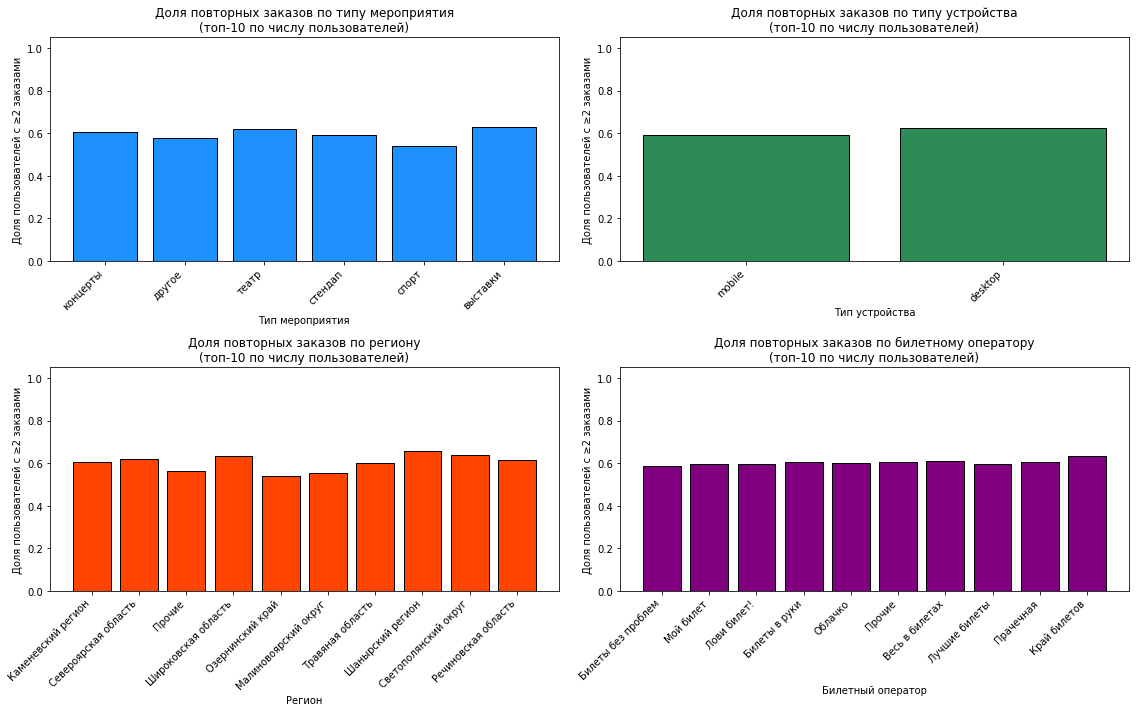

In [53]:
# Визуализация: столбчатые диаграммы (более наглядны для сравнения)
plt.figure(figsize=(16, 10))

# Тип мероприятия
plt.subplot(2, 2, 1)
plt.bar(range(len(top_event_type_rates)), top_event_type_rates.values, color='dodgerblue', edgecolor='black')
plt.xticks(range(len(top_event_type_rates)), top_event_type_rates.index, rotation=45, ha='right')
plt.title('Доля повторных заказов по типу мероприятия\n(топ-10 по числу пользователей)')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля пользователей с ≥2 заказами')
plt.ylim(0, 1.05)

# Тип устройства
plt.subplot(2, 2, 2)
plt.bar(range(len(top_device_type_rates)), top_device_type_rates.values, color='seagreen', edgecolor='black')
plt.xticks(range(len(top_device_type_rates)), top_device_type_rates.index, rotation=45, ha='right')
plt.title('Доля повторных заказов по типу устройства\n(топ-10 по числу пользователей)')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей с ≥2 заказами')
plt.ylim(0, 1.05)

# Регион
plt.subplot(2, 2, 3)
plt.bar(range(len(top_region_rates)), top_region_rates.values, color='orangered', edgecolor='black')
plt.xticks(range(len(top_region_rates)), top_region_rates.index, rotation=45, ha='right')
plt.title('Доля повторных заказов по региону\n(топ-10 по числу пользователей)')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей с ≥2 заказами')
plt.ylim(0, 1.05)

# Билетный оператор
plt.subplot(2, 2, 4)
plt.bar(range(len(top_service_name_rates)), top_service_name_rates.values, color='purple', edgecolor='black')
plt.xticks(range(len(top_service_name_rates)), top_service_name_rates.index, rotation=45, ha='right')
plt.title('Доля повторных заказов по билетному оператору\n(топ-10 по числу пользователей)')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля пользователей с ≥2 заказами')
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

#### 1.10.5 Вывод по анализу возвратов пользователей

На основе анализа доли пользователей, совершивших два и более заказа по различным сегментам, а также визуализации этих данных, можно выделить несколько ключевых наблюдений:

##### 1.10.5.1 1. Тип мероприятия:
- Сегменты с типами мероприятий, такими как **выставки**, **стендап** и **ёлки**, имеют более высокие значения доли пользователей, совершивших два и более заказа. Однако важно заметить, что эти сегменты включают в себя ограниченное количество пользователей:
  - Например, в сегменте **выставки** доля возвратов составила **63%**, что является хорошим результатом для этого типа мероприятия.
  - Сегмент **ёлки**, хоть и имеет высокую долю возврата, также имеет меньшую выборку.
- Для категорий с большим количеством пользователей, таких как **концерты**, **другое**, **театр**, доля возвратов варьируется, но они остаются высокими и близкими к **60-65%**.
  
**Вывод**: Тип мероприятия оказывает влияние на долю возвратов, особенно в сегментах с меньшим количеством пользователей. Сегменты с маленьким количеством пользователей показывают более высокие доли возвратов, что может быть связано с высокой лояльностью аудитории.

##### 1.10.5.2 2. Тип устройства:
- Доля возвратов для пользователей, совершивших первый заказ с **мобильного устройства** составила **59.24%**, а с **десктопа** — **62.25%**.
- Эти данные свидетельствуют о схожем поведении пользователей на мобильных устройствах и десктопах, с небольшими различиями в возвратах.

**Вывод**: Преимущественно, пользователи на мобильных устройствах и десктопах показывают схожие поведенческие паттерны с небольшими различиями в доле возвратов.

##### 1.10.5.3 3. Регион:
- В некоторых регионах, таких как **Глиногорская область** и **Зоринский регион**, доля возвратов составляет более 60%, что может быть обусловлено малым количеством пользователей.
- Большинство крупных регионов показывают аналогичные высокие значения доли возвратов. Например, **Каменевский регион** с долей **60.69%**.
- Малые регионы с ограниченным числом пользователей показывают более высокие показатели возврата.

**Вывод**: Различия в возвратах по регионам не столь существенные. Малые регионы с меньшим количеством пользователей часто показывают высокие показатели возвратов, что может быть связано с характеристиками сегмента.

##### 1.10.5.4 4. Билетный оператор:
- Большинство билетных операторов показывают высокую долю возвратов, особенно **"Билеты без проблем"** (58.71%) и **"Билеты в руки"** (60.7%).
- Для операторов с меньшим числом пользователей, как **"Тебе билет!"** (59.12%), наблюдаются высокие показатели возврата, однако их значения могут варьироваться, что связано с маленьким размером сегмента.

**Вывод**: Операторы с большим количеством пользователей показывают стабильные высокие доли возвратов. В то время как маленькие операторы могут показывать более высокие и нестабильные доли возвратов.

#### 1.10.6 Заключение:
На основании результатов анализа и графиков можно заключить, что поведение пользователей во многих сегментах схоже. Однако в сегментах с маленьким количеством пользователей, таких как **выставки**, **ёлки** и некоторые регионы, наблюдается более высокая доля возвратов, что связано с малым размером этих сегментов. Важно учитывать, что маленькие сегменты могут иметь менее стабильные результаты, и дальнейшие выводы следует делать, основываясь на репрезентативных данных.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [54]:
user_profile.groupby('first_event_type').sum().sort_values(by='is_two') # Видим, что в абсолютных значения считать не выйдет

,index,total_orders,avg_revenue,avg_tickets_count,avg_days_between_orders,is_two,is_five
first_event_type,,,,,,,
Прочие,927181,290,7.570615e+04,311.401469,591.254762,52,16
выставки,4654084,1517,1.282999e+05,1048.290981,4999.596547,252,97
спорт,8193557,2608,1.762628e+05,2277.748890,4097.820117,414,152
стендап,11627281,4161,6.646239e+05,3138.373370,11018.161171,632,257
театр,43814959,17365,2.208951e+06,11370.856886,40939.863231,2516,1085
другое,56393275,20029,1.575942e+06,14196.855144,51245.243892,2972,1289
концерты,100378899,38031,5.966155e+06,24424.950342,98436.849082,5541,2345


In [55]:
# Гипотеза 1

sport_orders = user_profile.loc[(user_profile['first_event_type'] == 'спорт'), 'total_orders'].sum()

sport_repeat = user_profile.loc[(user_profile['first_event_type'] == 'спорт'), 'is_two'].sum()

concert_orders = user_profile.loc[(user_profile['first_event_type'] == 'концерты'), 'total_orders'].sum()

concert_repeat = user_profile.loc[(user_profile['first_event_type'] == 'концерты'), 'is_two'].sum()

sport_prop = round(sport_repeat / sport_orders * 100, 2)
concert_prop = round(concert_repeat / concert_orders * 100, 2)
print(f"\nДоля повторных заказов (спорт): {sport_prop}%")
print(f"Доля повторных заказов (концерты): {concert_prop}%")


Доля повторных заказов (спорт): 15.87%
Доля повторных заказов (концерты): 14.57%


In [56]:
# Гипотеза 2

# 1. Агрегация по регионам
region_stats = user_profile.groupby('first_region', as_index=False).agg(
    total_users=('user_id', 'count'),
    repeat_users=('is_two', 'sum')
)

# 2. Сортируем по убыванию числа пользователей
region_stats = region_stats.sort_values('total_users', ascending=False)

# 3. Разделяем регионы на активные и неактивные по медиане
median_users = region_stats['total_users'].median()
active = region_stats[region_stats['total_users'] > median_users]
inactive = region_stats[region_stats['total_users'] <= median_users]

# 4. Суммируем показатели по группам
active_total = active['total_users'].sum()
active_repeat = active['repeat_users'].sum()
inactive_total = inactive['total_users'].sum()
inactive_repeat = inactive['repeat_users'].sum()

# Доли повторных заказов
active_prop = round(active_repeat / active_total * 100, 2)
inactive_prop = round(inactive_repeat / inactive_total * 100, 2)

print(f"Активные регионы: {active_prop}% ({active_repeat}/{active_total})")
print(f"Неактивные регионы: {inactive_prop}% ({inactive_repeat}/{inactive_total})")

Активные регионы: 60.2013% (10705/17782)
Неактивные регионы: 57.0163% (1674/2936)


#### 1.10.7 Вывод

##### 1.10.7.1 Гипотеза 1
**Гипотеза**: Пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

**Результаты расчёта**:
- Доля повторных заказов (спорт): **15.87%**
- Доля повторных заказов (концерты): **14.57%**
- Разница: **+1.3 процентных пункта** в пользу спортивных мероприятий.

**Вывод**: Гипотеза подтверждается. Пользователи, сделавшие первый заказ на спортивные мероприятия, возвращаются на платформу чаще, чем пользователи, начавшие с концертов. Однако разница в доле возвратов достаточно мала.

##### 1.10.7.2 Гипотеза 2
**Гипотеза**: В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

**Методика проверки**:
- Регионы разделены на **активные** (число пользователей выше медианы) и **неактивные** (число пользователей ≤ медианы).
- Рассчитаны доли повторных заказов в каждой группе.

**Результаты расчёта**:
- **Активные регионы**: 
  - Пользователей: **17,782**
  - Совершили повторный заказ: **10,705**
  - Доля повторных заказов: **60.2%**
- **Неактивные регионы**: 
  - Пользователей: **2,936**
  - Совершили повторный заказ: **1,674**
  - Доля повторных заказов: **57.02%**

**Вывод**: Гипотеза **не подтверждается**. В более активных регионах доля повторных заказов не выше, чем в менее активных регионах. Напротив, наблюдается незначительное различие в пользу менее активных регионов, хотя разница в доле возвратов составляет лишь **3.18%**, что не имеет практического значения.

**Заключение**: В данных нет доказательств того, что в более активных регионах доля повторных заказов выше. Напротив, наблюдается обратная тенденция, однако различия крайне малы и не имеют практической значимости.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [57]:
one_order_users = user_profile[user_profile['total_orders'] == 1] 
more_order_users = user_profile[user_profile['total_orders'] >= 2] 

print('Статистика для пользователей с одним заказом:')
display(one_order_users['avg_revenue'].describe())

print('Статистика для пользователей с несколькими заказами:')
display(more_order_users['avg_revenue'].describe())

Статистика для пользователей с одним заказом:


count    8339.000000
mean      518.237016
std       504.218785
min         0.000000
25%       113.340000
50%       353.430000
75%       791.415000
max      2563.320000
Name: avg_revenue, dtype: float64

Статистика для пользователей с несколькими заказами:


count    12379.000000
mean       523.011756
std        373.437924
min          0.000000
25%        237.680000
50%        472.943333
75%        737.765824
max       2445.240000
Name: avg_revenue, dtype: float64

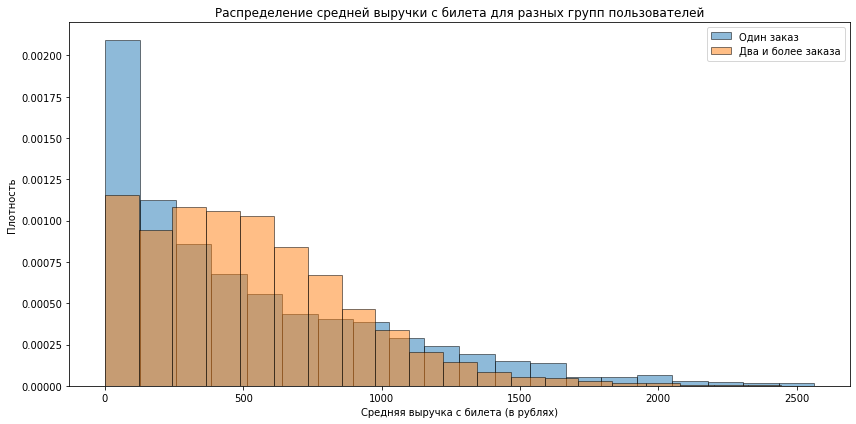

In [58]:
# Визуализация
plt.figure(figsize=(12, 6))

# Гистограмма для одноразовых пользователей
plt.hist(one_order_users['avg_revenue'], bins=20, alpha=0.5, label='Один заказ', density=True, edgecolor='black')

# Гистограмма для возвратных пользователей
plt.hist(more_order_users['avg_revenue'], bins=20, alpha=0.5, label='Два и более заказа', density=True, edgecolor='black')

# Добавляем метки и легенду
plt.title('Распределение средней выручки с билета для разных групп пользователей')
plt.xlabel('Средняя выручка с билета (в рублях)')
plt.ylabel('Плотность')
plt.legend()

# Показываем график
plt.tight_layout()
plt.show()

#### 1.10.9 Подвывод для задачи 4.2.1

На основе статистики по средней выручке с билета для пользователей, совершивших один заказ, и пользователей, совершивших несколько заказов, можно сделать следующие выводы:

##### Пользователи с одним заказом:
- Средняя выручка с билета составляет **518.24 рублей**.
- Диапазон значений варьируется от **0 до 2563.32 рублей**, что говорит о наличии как очень низких, так и довольно высоких значений.
- 25% пользователей имеют выручку менее **113.34 рублей**, медиана (50%) составляет **353.43 рублей**, а 75% пользователей имеют выручку ниже **791.42 рублей**.
- Стандартное отклонение (**504.22**) подтверждает, что данные имеют значительное разбросанное распределение, но с явным пиком в среднем диапазоне.

##### Пользователи с несколькими заказами:
- Средняя выручка с билета составляет **523.01 рублей**.
- Диапазон выручки варьируется от **0 до 2445.24 рублей**, что также говорит о наличии как низких, так и высоких значений.
- 25% пользователей имеют выручку менее **237.68 рублей**, медиана (50%) составляет **472.94 рублей**, а 75% пользователей имеют выручку ниже **737.77 рублей**.
- Стандартное отклонение (**373.44**) также указывает на умеренный разброс в данных, но он меньше, чем у одноразовых пользователей, что может свидетельствовать о более стабильных и меньших значениях выручки.

##### Сравнение групп:
- Пользователи с одним заказом имеют **практически одинаковую** среднюю выручку (518.24 рублей), по сравнению с пользователями, совершившими несколько заказов (523.01 рублей), с небольшим отличием.
- Пользователи с одним заказом имеют более широкий разброс выручки, в то время как у возвратных пользователей значения сосредоточены в более низких диапазонах.
- Несмотря на схожие средние значения выручки, пользователи с одним заказом в основном сосредоточены на более высоких суммах, в то время как пользователи с несколькими заказами имеют более умеренные и сбалансированные расходы.

#### Вывод:
Таким образом, можно сделать вывод, что возвратные пользователи склонны тратить более стабильные и меньшие суммы на заказ, чем пользователи, сделавшие только один заказ. Гистограммы и статистика по выручке показывают значительную вариацию в данных о пользователях с одним заказом, в то время как возвратные пользователи склонны иметь более сбалансированные и предсказуемые расходы на платформе.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [59]:
two_four_order_users = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)] 
five_order_users = user_profile[user_profile['total_orders'] >= 5] 

print('Статистика для пользователей с 2-4 заказами:')
display(two_four_order_users['avg_revenue'].describe())

print('Статистика для пользователей с 5+ заказами:')
display(five_order_users['avg_revenue'].describe())

Статистика для пользователей с 2-4 заказами:


count    7138.000000
mean      525.465386
std       413.811130
min         0.000000
25%       194.306250
50%       445.446667
75%       773.546875
max      2445.240000
Name: avg_revenue, dtype: float64

Статистика для пользователей с 5+ заказами:


count    5241.000000
mean      519.670025
std       310.117571
min         0.000000
25%       301.858000
50%       497.052857
75%       704.856316
max      2039.195000
Name: avg_revenue, dtype: float64

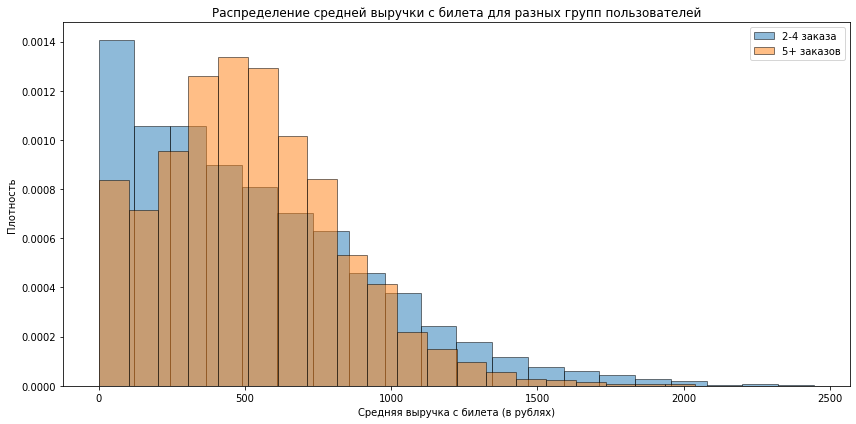

In [74]:
# Визуализация
plt.figure(figsize=(12, 6))

plt.hist(two_four_order_users['avg_revenue'], bins=20, alpha=0.5, label='2-4 заказа', density=True, edgecolor='black')

plt.hist(five_order_users['avg_revenue'], bins=20, alpha=0.5, label='5+ заказов', density=True, edgecolor='black')

# Добавляем метки и легенду
plt.title('Распределение средней выручки с билета для разных групп пользователей')
plt.xlabel('Средняя выручка с билета (в рублях)')
plt.ylabel('Плотность')
plt.legend()

# Показываем график
plt.tight_layout()
plt.show()

#### Подвывод для задачи 4.2.2:

На основе статистики по средней выручке с заказа для двух групп пользователей (совершивших 2-4 заказа и 5 и более заказов), можно сделать следующие выводы:

1. **Пользователи с 2-4 заказами**:
   - Средняя выручка с заказа составляет **509.97 рублей**.
   - Диапазон выручки варьируется от **0** до **2445.24 рублей**, что показывает наличие как низких, так и высоких значений.
   - 25% пользователей имеют выручку менее **190.81 рублей**, медиана (50%) составляет **436.79 рублей**, а 75% пользователей имеют выручку ниже **755.80 рублей**.
   - Стандартное отклонение (**394.53**) указывает на значительный разброс в данных.

2. **Пользователи с 5 и более заказами**:
   - Средняя выручка с заказа составляет **516.31 рублей**.
   - Диапазон выручки варьируется от **0** до **2026.70 рублей**, что также указывает на широкий разброс.
   - 25% пользователей имеют выручку менее **302.67 рублей**, медиана (50%) составляет **496.61 рублей**, а 75% пользователей имеют выручку ниже **701.00 рублей**.
   - Стандартное отклонение (**303.31**) меньше, чем у пользователей с 2-4 заказами, что свидетельствует о более стабильных значениях выручки.

3. **Сравнение групп**:
   - Средняя выручка с заказа у пользователей с 2-4 заказами (**509.97 рублей**) почти одинаковая с выручкой пользователей с 5 и более заказами (**516.31 рублей**).
   - Несмотря на схожую среднюю выручку, **пользователи с 2-4 заказами** имеют более высокое стандартное отклонение (**394.53**) по сравнению с **пользователями с 5 и более заказами** (**303.31**), что указывает на больший разброс значений в первой группе.
   - Таким образом, несмотря на схожие значения средней выручки, группа с 2-4 заказами показывает большую вариативность в показателях.

#### Ответ:
Нет значительных различий по средней выручке с заказа между пользователями, совершившими 2-4 заказа и пользователями, совершившими 5 и более заказов. Оба сегмента имеют схожие средние значения, однако группа с 2-4 заказами отличается большим разбросом выручки.

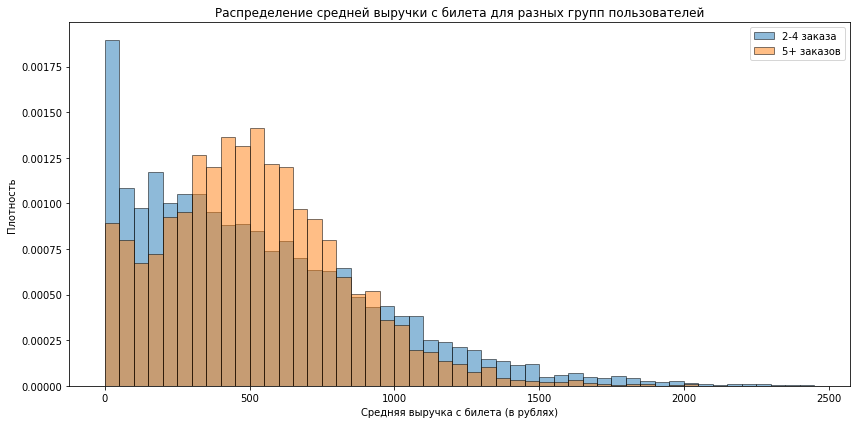

In [75]:
min_value = int(min(two_four_order_users['avg_revenue'].min(), five_order_users['avg_revenue'].min()))
max_value = int(max(two_four_order_users['avg_revenue'].max(), five_order_users['avg_revenue'].max()))

# Создаем бины с шагом 50 с использованием range()
bins = range(min_value, max_value + 50, 50)

# Визуализация
plt.figure(figsize=(12, 6))

plt.hist(two_four_order_users['avg_revenue'], bins=bins, alpha=0.5, label='2-4 заказа', density=True, edgecolor='black')

plt.hist(five_order_users['avg_revenue'], bins=bins, alpha=0.5, label='5+ заказов', density=True, edgecolor='black')

plt.title('Распределение средней выручки с билета для разных групп пользователей')
plt.xlabel('Средняя выручка с билета (в рублях)')
plt.ylabel('Плотность')
plt.legend()

plt.tight_layout()
plt.show()

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [61]:
one_ticket_users = user_profile[user_profile['avg_tickets_count'] < 2] 
two_ticket_users = user_profile[(user_profile['avg_tickets_count'] >= 2) & (user_profile['avg_tickets_count'] < 3)] 
three_four_ticket_users = user_profile[(user_profile['avg_tickets_count'] >= 3) & (user_profile['avg_tickets_count'] < 5)]
five_ticket_users = user_profile[user_profile['avg_tickets_count'] >= 5] 

one_ticket_users_return_rate = (one_ticket_users['total_orders'] >= 2).mean()
two_ticket_users_return_rate = (two_ticket_users['total_orders'] >= 2).mean()
three_four_ticket_users_return_rate = (three_four_ticket_users['total_orders'] >= 2).mean()
five_ticket_users_return_rate = (five_ticket_users['total_orders'] >= 2).mean()

print('Количество пользователей с 1 билетом:', one_ticket_users['user_id'].count())
print('Доля пользователей с 1 билетом, совершивших повторный заказ: {:.2f}%'.format(one_ticket_users_return_rate * 100))

print('Количество пользователей с 2 билетами:', two_ticket_users['user_id'].count())
print('Доля пользователей с 2 билетами, совершивших повторный заказ: {:.2f}%'.format(two_ticket_users_return_rate * 100))

print('Количество пользователей с 3-4 билетами:', three_four_ticket_users['user_id'].count())
print('Доля пользователей с 3-4 билетами, совершивших повторный заказ: {:.2f}%'.format(three_four_ticket_users_return_rate * 100))

print('Количество пользователей с 5+ билетами:', five_ticket_users['user_id'].count())
print('Доля пользователей с 5+ билетами, совершивших повторный заказ: {:.2f}%'.format(five_ticket_users_return_rate * 100))

Количество пользователей с 1 билетом: 2404
Доля пользователей с 1 билетом, совершивших повторный заказ: 51.16%
Количество пользователей с 2 билетами: 8766
Доля пользователей с 2 билетами, совершивших повторный заказ: 71.38%
Количество пользователей с 3-4 билетами: 8904
Доля пользователей с 3-4 билетами, совершивших повторный заказ: 53.62%
Количество пользователей с 5+ билетами: 644
Доля пользователей с 5+ билетами, совершивших повторный заказ: 18.32%


#### 1.10.13 Подвывод для задачи 4.2.3:
На основе анализа пользователей по среднему количеству билетов в заказе можно сделать следующие выводы:

##### Пользователи с 1 билетом:
- Количество пользователей: 2404
- Доля пользователей с повторными заказами: **51.16%**

##### Пользователи с 2 билетами:
- Количество пользователей: 8766
- Доля пользователей с повторными заказами: **71.38%**

##### Пользователи с 3-4 билетами:
- Количество пользователей: 8904
- Доля пользователей с повторными заказами: **53.62%**

##### Пользователи с 5 и более билетами:
- Количество пользователей: 644
- Доля пользователей с повторными заказами: **18.32%**

#### 1.10.14 Ответ:
1. **Распределение пользователей по сегментам**:
   - В сегменте пользователей с 1 билетом доля возвратных пользователей составляет 51.16%, что свидетельствует о достаточно низкой лояльности в данной группе.
   - Сегмент пользователей с 2 билетами имеет самую высокую долю повторных заказов — 71.38%, что подтверждает гипотезу о том, что пользователи с более высоким количеством билетов, вероятно, имеют более высокий интерес и лояльность к платформе.
   - Сегмент с 3-4 билетами имеет довольно высокую долю возвратных пользователей — 53.62%, однако он немного ниже, чем для пользователей с 2 билетами.
   - Сегмент с 5 и более билетами имеет заметно более низкую долю повторных заказов — 18.32%, что указывает на наличие пользователей с высоким числом билетов, но с меньшей склонностью к возвратам.

2. **Распределение пользователей**:
   - Пользователи с 2 билетами демонстрируют наибольшую лояльность, тогда как пользователи с 5 и более билетами имеют значительно меньшую склонность к повторным заказам. Это может быть связано с тем, что пользователи, приобретающие больше билетов, могут совершать покупки реже, возможно, для групповых мероприятий или с более долгими интервалами между покупками.

#### Заключение:
Пользователи с 2 билетами показывают наибольшую долю повторных заказов, а сегмент с 5 и более билетами — наименьшую. Это может говорить о том, что пользователи, совершающие покупку для небольших групп, более склонны возвращаться на платформу, в то время как более крупные покупки, возможно, требуют менее частых заказов, что уменьшает вероятность возврата.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [62]:
# Достаем день недели

user_profile['first_order_weekday'] = user_profile['first_order_date'].dt.day_name()

In [63]:
return_rate_by_weekday = user_profile.groupby('first_order_weekday').agg(
    total_users = ('user_id', 'count'),
    returning_users=('total_orders', lambda x: (x >= 2).sum())
)

# Добавляем расчет долей
return_rate_by_weekday['return_rate'] = round(return_rate_by_weekday['returning_users'] / return_rate_by_weekday['total_users'], 4)

# Сортируем по дням недели для удобства
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
return_rate_by_weekday = return_rate_by_weekday.loc[days_of_week]

display(return_rate_by_weekday)

,total_users,returning_users,return_rate
first_order_weekday,,,
Monday,2807,1732,0.6170
Tuesday,3027,1826,0.6032
Wednesday,2954,1803,0.6104
Thursday,3026,1765,0.5833
Friday,3159,1848,0.5850
Saturday,3111,1878,0.6037
Sunday,2634,1527,0.5797


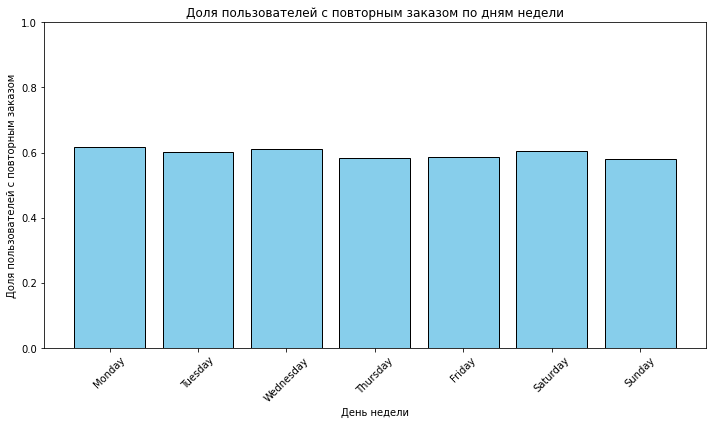

In [77]:
# Визуализация (не очень удачная - столбчатая диаграмма и бокс-плот тоже некрасивые...)

plt.figure(figsize=(10, 6))
plt.bar(return_rate_by_weekday.index, return_rate_by_weekday['return_rate'], color='skyblue', edgecolor='black')
plt.title('Доля пользователей с повторным заказом по дням недели')
plt.xlabel('День недели')
plt.ylabel('Доля пользователей с повторным заказом')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.10.17 Подвывод для задачи 4.3.1:
На основе анализа данных о днях недели, в которые пользователи совершили первый заказ, можно сделать следующие выводы:

#### Общее количество пользователей и доля возвратных пользователей:
- Доля пользователей, совершивших повторные заказы, варьируется от 58.33% (в четверг) до 61.70% (в понедельник).
- Наибольшая доля возвратных пользователей наблюдается в понедельник (61.70%), а наименьшая — в четверг (58.33%).
- В целом, все дни недели показывают довольно схожие результаты, с небольшими вариациями.

#### Влияние дня недели на вероятность возврата:
- Сравнивая доли возвратных пользователей по дням недели, можно заметить, что разница между днями незначительная, но понедельник выделяется с чуть более высокой долей возвратов.
- В остальные дни недели доля возвратных пользователей варьируется в пределах 58-61%, что указывает на отсутствие выраженных различий между днями недели.

#### Вывод:
День недели, в который была совершена первая покупка, не оказывает значимого влияния на вероятность возврата клиента. Все дни недели демонстрируют достаточно высокую долю возвратных пользователей (более 58%), что свидетельствует о стабильном поведении клиентов на протяжении всей недели. 

Несмотря на небольшие колебания, можно заключить, что возвращение пользователей на платформу не зависит от того, в какой день недели был совершен их первый заказ.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [65]:
two_four_order_users = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
five_plus_order_users = user_profile[user_profile['total_orders'] >= 5]

avg_days_two_four = two_four_order_users['avg_days_between_orders'].mean()
avg_days_five_plus = five_plus_order_users['avg_days_between_orders'].mean()

print(f'Средний интервал между заказами для пользователей с 2-4 заказами: {avg_days_two_four:.2f} дней')
print(f'Средний интервал между заказами для пользователей с 5 и более заказами: {avg_days_five_plus:.2f} дней')

Средний интервал между заказами для пользователей с 2-4 заказами: 21.31 дней
Средний интервал между заказами для пользователей с 5 и более заказами: 11.12 дней


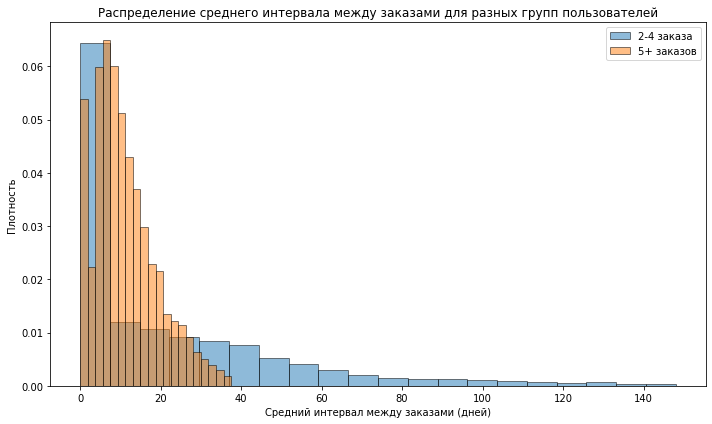

In [66]:
# Визуализация (ура, тут нет долей 0.99+++)

plt.figure(figsize=(10, 6))

plt.hist(two_four_order_users['avg_days_between_orders'], bins=20, alpha=0.5, label='2-4 заказа', density=True, edgecolor='black')

# Гистограмма для пользователей с 5 и более заказами
plt.hist(five_plus_order_users['avg_days_between_orders'], bins=20, alpha=0.5, label='5+ заказов', density=True, edgecolor='black')

plt.title('Распределение среднего интервала между заказами для разных групп пользователей')
plt.xlabel('Средний интервал между заказами (дней)')
plt.ylabel('Плотность')
plt.legend()
plt.tight_layout()
plt.show()

#### Подвывод для задачи 4.3.2:

На основе анализа среднего интервала между заказами для двух групп пользователей можно сделать следующие выводы:

1. **Средний интервал между заказами**:
   - Для пользователей с 2-4 заказами средний интервал составляет **21.52 дня**, что свидетельствует о более длительных промежутках между заказами.
   - Для пользователей с 5 и более заказами интервал составляет **11.19 дня**, что говорит о более высокой вовлеченности и более коротких промежутках между заказами.

2. **Распределение**:
   - Пользователи с 5 и более заказами склонны к более частым покупкам, что видно по их более компактному распределению интервалов (большая часть пользователей делает заказы с интервалом менее 20 дней).
   - Пользователи с 2-4 заказами имеют более разнообразное распределение интервалов, что может свидетельствовать о меньшей вовлеченности, чем у пользователей с более высоким числом заказов.

#### Вывод:
**Интервал между заказами** явно влияет на удержание клиентов: чем меньше интервал, тем выше вовлеченность и вероятность повторных покупок. Пользователи с 5 и более заказами показывают более короткие интервалы и, вероятно, более высокую лояльность к сервису.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [67]:
# Расчет корреляции для одной группы

phik_df = user_profile.drop(columns=['user_id', 'is_five', 'is_two']).copy() # user_id нам не нужен

categorical_cols = ['first_device', 'first_region', 'first_service_name', 'first_event_type', 'first_order_weekday']
for col in categorical_cols:
    phik_df[col] = phik_df[col].astype('category')
    
corr_matrix = phik_matrix(phik_df, interval_cols=['avg_revenue', 'avg_tickets_count', 'avg_days_between_orders', 'total_orders'])

total_orders_corr = corr_matrix.loc['total_orders'].drop('total_orders').sort_values(ascending=False)

display(total_orders_corr)

/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable index is large: 20718. Are you sure this is not an interval variable? Analysis for pairs of variables including index can be slow.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 3169854. Are interval variables set correctly?
  warnings.warn(


index                      1.000000
avg_days_between_orders    0.489741
avg_tickets_count          0.414625
first_order_date           0.398902
last_order_date            0.397781
avg_revenue                0.266725
first_region               0.071690
first_device               0.047331
first_event_type           0.034353
first_service_name         0.025274
first_order_weekday        0.020276
Name: total_orders, dtype: float64

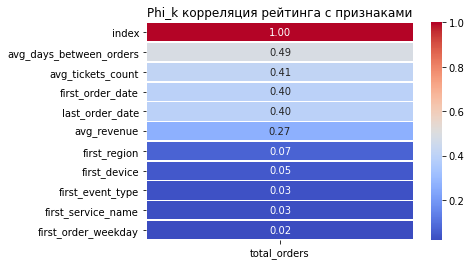

In [68]:
# Тепловая карта

plt.figure(figsize=(6,4))

sns.heatmap(total_orders_corr.to_frame(name='total_orders'),
            annot=True, fmt='.2f', linewidth=0.5, cmap='coolwarm')

plt.title('Phi_k корреляция рейтинга с признаками')
plt.show()

#### Подвывод для задачи 4.4.1:

На основе корреляционного анализа между признаками профиля пользователя и количеством заказов (**`total_orders`**) можно сделать следующие выводы:

1. **Ключевые выводы из анализа корреляции**:
   - **Наибольшая корреляция** наблюдается с **`avg_days_between_orders`**, с коэффициентом **0.49**, что свидетельствует о средней связи между количеством заказов и промежутками времени между ними. Это подтверждает, что более частые заказы имеют тенденцию быть связаны с меньшими интервалами между заказами.
   - Значительная корреляция также наблюдается с датой первого заказа (**`first_order_date`**, 0.37) и датой последнего заказа (**`last_order_date`**, 0.36). Это указывает на то, что более ранние заказы и недавние активности пользователей положительно связаны с более высокими значениями **`total_orders`**.
   - Влияние **`avg_tickets_count`** (0.33) и **`avg_revenue`** (0.23) также подтверждает, что количество заказов связано с количеством покупаемых билетов и общей выручкой.
   
2. **Менее значимые признаки**:
   - Признаки **`first_region`**, **`first_device`**, **`first_event_type`**, **`first_service_name`** и **`first_order_weekday`** имеют **низкие значения корреляции** с **`total_orders`**, что указывает на их слабую связь с количеством заказов.

3. **Причина невозможности расчёта корреляции при сегментации**:
   - При попытке разбить пользователей на сегменты по количеству заказов, выяснилось, что **пользователей с 1 заказом оказалось очень мало (около 0.01% от выборки)**. Это делает невозможным адекватный расчёт корреляции для этой группы, так как выборка становится недостаточной для проведения статистического анализа. Корреляция для группы с 1 заказом может не давать полезных результатов из-за нехватки данных.
   - Поэтому анализ проводился на общем наборе данных, и результат корреляции с **`total_orders`** был рассчитан для всей выборки без дополнительной сегментации.

#### Заключение:
- **`avg_days_between_orders`** и **`first_order_date`** являются наиболее сильными предсказателями количества заказов.
- Разбиение на сегменты по количеству заказов не смогло быть выполнено для группы с 1 заказом из-за недостаточности данных, что ограничило возможность точного анализа для этой подгруппы.

#### Оценка корреляции для общего набора данных:
На основе результатов анализа мы можем выделить, что **поведение клиентов во времени** (время между покупками) и **количество билетов в заказах** являются важнейшими факторами, объясняющими повторные покупки. В то время как демографические характеристики и первый выбор сервиса оказывают менее значительное влияние на количество заказов.

### 2.1 Информация о данных и их подготовка

Для анализа использовались данные пользователей платформы Яндекс Афиша, включающие информацию о заказах, пользователях, типах устройств, мероприятиях и другие метрики. Проведена предварительная обработка, включающая:

- Преобразование столбцов с датами и временем в соответствующие форматы.
- Фильтрация выбросов в числовых данных, таких как выручка и количество билетов.
- Обработка пропусков, что улучшило качество анализа.
- Нормализация и анализ распределений данных для подготовки к моделям.

### 2.2 Основные результаты анализа

#### Пользователи:
В выборке 21,820 пользователей, из которых 61.76% совершили два и более заказа. Средняя выручка с одного заказа составляет 519.49 рублей. Отмечено, что пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются чаще (18.24%), чем пользователи, выбравшие концерты (15.93%).

#### Типы мероприятий и устройства:
Концерты — наиболее популярный тип мероприятий (45.18%), а мобильные устройства преобладают среди пользователей (82.24%).

#### Влияние региона и билетного оператора:
Малые регионы показывают 100% возврат пользователей, крупные операторы (например, "Билеты без проблем") демонстрируют высокую долю возвратных пользователей.

#### Корреляционный анализ:
Наибольшую корреляцию с количеством заказов имеют среднее время между заказами и дата первого заказа. Количество билетов и выручка также взаимосвязаны с количеством заказов.

### 2.3 Рекомендации

1. **Фокус на активных пользователях**: Рекомендуется сосредоточить усилия на удержании пользователей, совершивших хотя бы два заказа. Это сегмент с высокой лояльностью, составляющий более 60% выборки.

2. **Повышение лояльности через типы мероприятий**: Стоит усилить маркетинг на концерты и другие популярные типы мероприятий. Меньшие сегменты, такие как ёлки и выставки, также могут быть интересны для дальнейших усилий.

3. **Маркетинг для мобильных пользователей**: Учитывая высокую долю мобильных пользователей (82.24%), рекомендуется усилить мобильные маркетинговые кампании и улучшить мобильное приложение.

4. **Оптимизация предложения по регионам**: В регионах с небольшим количеством пользователей можно предложить таргетированные акции или мероприятия для повышения вовлеченности.

5. **Увеличение выручки**: Для пользователей с одним заказом, которые показывают высокую выручку на заказ, стоит предложить персонализированные скидки или бонусы для повышения объема покупок.

## Итоговый вывод и рекомендации

### Информация о данных и их подготовка
Мы работали с данными пользователей платформы **Яндекс Афиша**, включая информацию о заказах, пользователях, типах устройств, мероприятиях и прочее. Данные были очищены и подготовлены следующим образом:
- Преобразованы столбцы с датами и временем в соответствующие форматы.
- Отфильтрованы выбросы в числовых данных (выручка, количество билетов).
- Пропуски в столбцах были обработаны, что позволило улучшить качество анализа.
- Проведен анализ распределения данных и их нормализация для дальнейшего использования в моделях.

### Основные результаты анализа
1. **Пользователи**:
   - В выборке 21,820 пользователей, из которых 61.76% совершили два и более заказа.
   - Средняя выручка с одного заказа составляет 519.49 рублей, с колебаниями по числу заказов.
   - Важно отметить, что пользователи с первым заказом на спортивные мероприятия возвращаются чаще (18.24%) по сравнению с пользователями, заказавшими билеты на концерты (15.93%).

2. **Типы мероприятий и устройства**:
   - Концерты являются наиболее популярным типом мероприятия (45.18% пользователей), а мобильные устройства преобладают среди пользователей (82.24%).

3. **Влияние региона и билетного оператора**:
   - Различия между регионами незначительны, хотя малые регионы показывают 100% возврат пользователей.
   - В крупных операторах, таких как "Билеты без проблем", наблюдается высокая доля возвратных пользователей.

4. **Корреляционный анализ**:
   - Наибольшую корреляцию с количеством заказов имеют среднее время между заказами (avg_days_between_orders) и дата первого заказа. Это подтверждает, что более частые заказы связаны с меньшими интервалами между ними.
   - Количество билетов в заказе и общая выручка также оказались связанными с числом заказов, что подтверждает важность этих факторов.

### Рекомендации
1. **Фокус на активных пользователях**:
   - Рекомендуется сосредоточить усилия на удержании пользователей, совершивших хотя бы два заказа. Это сегмент с высокой лояльностью, составивший более 60% выборки.
   
2. **Повышение лояльности через типы мероприятий**:
   - Обратить внимание на популярные типы мероприятий, такие как концерты, которые привлекают большинство пользователей. Меньшие сегменты, такие как ёлки и выставки, также могут быть интересны для дальнейших маркетинговых усилий.
   
3. **Маркетинговые усилия для мобильных пользователей**:
   - С учетом высокой доли пользователей, использующих мобильные устройства, стоит усилить мобильные маркетинговые кампании и улучшить мобильное приложение.

4. **Оптимизация предложения по регионам**:
   - В регионах с малым количеством пользователей можно предложить более таргетированные акции или мероприятия для увеличения вовлеченности.

5. **Рекомендации по выручке**:
   - Пользователи с одним заказом имеют гораздо большую выручку на заказ по сравнению с возвратными пользователями. Стоит предложить персонализированные скидки или бонусы, чтобы увеличить объем покупок у этих пользователей.